# Run a retrieval of an ACS solar occultation observation

In this notebook, we are going to show how to use the *acs* Python package to run retrievals for the ACS solar occultation observations using the archNEMESIS radiative transfer algorithm. 

In particular, we are going to assume that we already have created a Measurement class with the information regarding the measurement we want to retrieve. In this measurement, we are observing an absorption band of $^{13}$CO$_2$ encompassed within the spectral range of ACS NIR. Specifically, this spectral range coincides with the diffraction order #52 of ACS NIR.

Here, we are going to run a retrieval to infer the vertical profile of $^{13}$CO$_2$.

In [1]:
import acs
import archnemesis as ans
import matplotlib.pyplot as plt
import numpy as np

## 1. Reading the Measurement

First of all, we read the information regarding the Measurement. This will allready give is information about the spectral range and the geometry of the observations.

In [2]:
filename_true = "synthetic_ini_file"

In [3]:
Measurement = ans.Measurement_0()
Measurement.read_hdf5(filename_true)

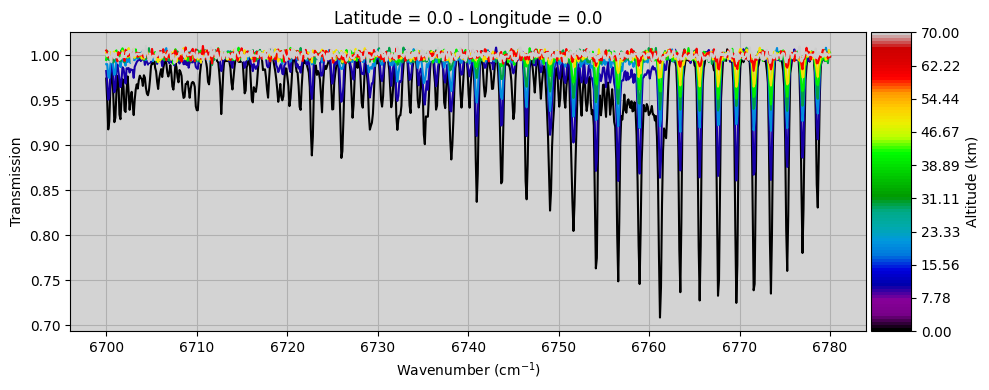

In [4]:
Measurement.plot_SO()

## 2. Creating reference classes

Now, we are going to initialise all the classes as if we were going to run a forward model. In principle, we do not know the characteristics of the atmosphere that gave rise to the observed spectrum. Therefore, we are going to assume some atmospheric properties, and then will refine these by performing the retrieval and reconstructing the observed transmission spectra.

### 2.1. Atmosphere

Even if in a real retrieval we would not know the characteristics from the Atmosphere, here we do since we generated the measured spectra ourselves. However, to start from a different position, we are going to multiply the atmospheric pressure by a factor of 1.5 so that we do not start from the same answer we are supposed to guess from the retrieval.

In [5]:
Atmosphere = ans.Atmosphere_0()
Atmosphere.read_hdf5(filename_true)
Atmosphere.P *= 1.5  #Multiplying the pressure by 1.5

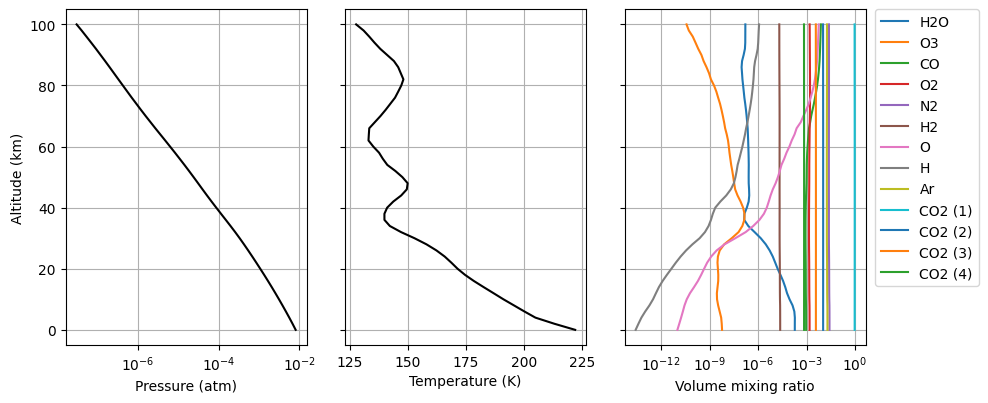

In [6]:
Atmosphere.plot_Atm()

### 2.2. Spectroscopy

In [7]:
#Defining the path to the line-by-line look-up tables
lbl_tables = ["/srv/workspace/data/nemesis/spectroscopy/lbltables/acsnir/archnem/co2_iso1_acsnir_order52.h5",
              "/srv/workspace/data/nemesis/spectroscopy/lbltables/acsnir/archnem/co2_iso2_acsnir_order52.h5"]

In [8]:
Spectroscopy = acs.archnemesis.spectroscopy.create_spectroscopy_lookup_class(lbl_tables)

## 3. Creating the archNEMESIS input file

In [9]:
filename = "retrieval_co2_iso2"

In [10]:
acs.archnemesis.files.create_files_forward_model(filename,Atmosphere,Measurement,Spectroscopy)

## 4. Running a forward model

First of all, based on our assumptions of the prior reference atmosphere, we can generate a spectrum and see how it compares to the measure one. That will already tell us some information about whether our reference atmosphere is far from the "true" one.

In our case, since we are looking at an absorption band of $^{13}$CO$_2$, this will tell us whether the assumed number density of $^{13}$CO$_2$ in our reference atmosphere is far from the true one.

In [11]:
#Reading the input files
Atmosphere,Measurement,Spectroscopy,Scatter,Stellar,Surface,CIA,Layer,Variables,Retrieval,Telluric = ans.Files.read_input_files_hdf5(filename)

INFO :: read_apr :: Variables_0.py-823 :: 
Variables_0 :: read_apr :: varident [0 0 2]. Constructed model "Model2" (id=2)
INFO :: read_apr :: Variables_0.py-826 ::   Model2:
  |- id : 2
  |- parent classes: PreRTModelBase
  |- description: In this model, the atmospheric parameters are scaled using a
  |               single factor with  respect to the vertical profiles in the
  |               reference atmosphere
  |- n_state_vector_entries : 1
  |- state_vector_slice : slice(0, 1, None)
  |- state_vector_start : 0
  |- target : 1
  |- Parameters:
  |  |- scaling_factor :
  |  |  |- slice : slice(0, 1, None)
  |  |  |- unit : PROFILE_TYPE
  |  |  |- description: Scaling factor applied to the reference profile
  |  |  |- apriori value : 1.0


In [12]:
#Running forward model
ForwardModel = ans.ForwardModel_0(Atmosphere=Atmosphere,Surface=Surface,Measurement=Measurement,Spectroscopy=Spectroscopy,Stellar=Stellar,Scatter=Scatter,CIA=CIA,Layer=Layer,Variables=Variables)
SPECONV_apr = ForwardModel.nemesisSOfm()
del ForwardModel

INFO :: __init__ :: ForwardModel_0.py-297 :: Checking atmospheric gasses have spectroscopy data.
# WARNING #########################################################################

The following atmospheric gasses ARE NOT PRESENT in the spectroscopy data and WILL NOT CONTRIBUTE TO OPACITY:

    H2O (id 1) isotopologue 0
    O3 (id 3) isotopologue 0
    CO (id 5) isotopologue 0
    O2 (id 7) isotopologue 0
    N2 (id 22) isotopologue 0
    H2 (id 39) isotopologue 0
    O (id 45) isotopologue 0
    H (id 48) isotopologue 0
    Ar (id 76) isotopologue 0
    CO2 (id 2) isotopologue 3
    CO2 (id 2) isotopologue 4

To deactivate this warning place a path to a line-by-line-table file for these gasses in one of the following locations (depending upon your input file type):

    [HDF5 Input]
        In the "wasp121.h5" file, add an entry to "/Spectroscopy/LOCATION"
        and update "/Spectroscopy/NGAS" appropriately.

    [LEGACY Input]
        Add an entry to the "wasp121.lls" file.

# END

Now we can plot the spectrum, and since we have multiplied the pressure by a factor of 1.5 with respect to the true answer, we should see some difference between this forward model and the measurement.

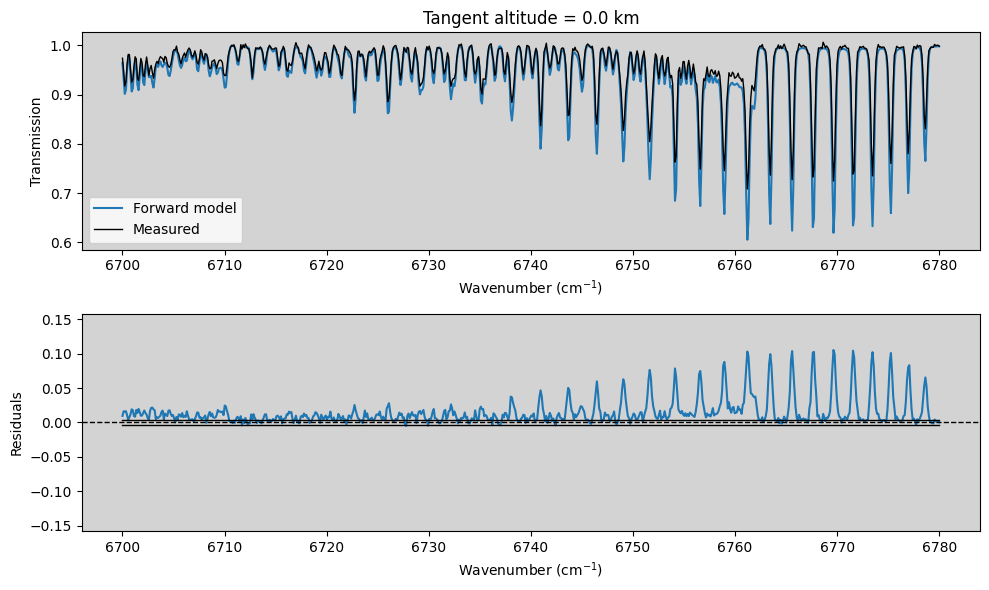

In [13]:
igeom = 0

fig,(ax1,ax2) = plt.subplots(2,1,figsize=(10,6))
ax1.plot(Measurement.VCONV[:,igeom],SPECONV_apr[:,igeom],c='tab:blue',label="Forward model")
ax1.plot(Measurement.VCONV[:,igeom],Measurement.MEAS[:,igeom],c='black',label="Measured",linewidth=1.)
ax1.legend()
ax1.set_xlabel(r'Wavenumber (cm$^{-1}$)')
ax1.set_ylabel('Transmission')
ax1.set_facecolor('lightgray')
ax1.set_title(f"Tangent altitude = {Measurement.TANHE[igeom,0]} km")

ax2.plot(Measurement.VCONV[:,igeom],Measurement.MEAS[:,igeom]-SPECONV_apr[:,igeom],c='tab:blue')
ax2.plot(Measurement.VCONV[:,igeom],Measurement.ERRMEAS[:,igeom],c='black',linewidth=1.)
ax2.plot(Measurement.VCONV[:,igeom],-Measurement.ERRMEAS[:,igeom],c='black',linewidth=1.)
ax2.axhline(0.,c='black',linewidth=1.,linestyle="--")
maxval = np.max( np.abs(Measurement.MEAS[:,igeom]-SPECONV_apr[:,igeom]) )
ax2.set_ylim(-maxval*1.5,maxval*1.5)
ax2.set_xlabel(r'Wavenumber (cm$^{-1}$)')
ax2.set_ylabel('Residuals')
ax2.set_facecolor('lightgray')

plt.tight_layout()

## 5. Performing retrieval

### 5.1. Writing .apr file

In the a priori file (.apr), it is where we define the parameters we want to modify in our atmosphere to fit the spectrum. 

In this case, we want to modify the vertical profile of $^{13}$CO$_2$ in the atmosphere.

In [14]:
retrieve_continuous_prof = True

gasID_retrieve = [2]
isoID_retrieve = [2]
cont_clen = [1.5]       #Correlation length (typically 1.5)
cont_err = [0.5]        #Fractional error for the uncertainty in the retrieved parameter

In [15]:
acs.archnemesis.files.create_apr_file(filename,
                                Atmosphere, 
                                Measurement,
                                retrieve_continuous_prof=retrieve_continuous_prof,
                                varID1=gasID_retrieve,varID2=isoID_retrieve,
                                cont_clen=cont_clen,cont_err=cont_err)

### 5.2. Writing retrieval parameters

In [16]:
#Retrieval class
Retrieval = ans.OptimalEstimation_0(IRET=0)
Retrieval.NITER = 5        #Number of iterations
Retrieval.PHILIMIT = 0.1   #Convergence criterion
Retrieval.NCORES = 1       #Number of available cores
Retrieval.assess_input()

#Writing into input file
Retrieval.write_input_hdf5(filename)

### 5.3. Running retrieval

In [17]:
legacy_files=False    #Reading the standard NEMESIS files to compare the results from both codes
retrieval_method=0    #Optimal Estimtion
NCores=None           #Since we are not including scattering in this calculation (Scatter.ISCAT=0), the Jacobian is calculated analytically
nemesisSO = True      #Flag to indicate that we are analysing a solar occultation observation

ans.Retrievals.retrieval_nemesis(filename,legacy_files=legacy_files,retrieval_method=retrieval_method,NCores=NCores,nemesisSO=nemesisSO)

INFO :: read_apr :: Variables_0.py-823 :: 
Variables_0 :: read_apr :: varident [2 2 0]. Constructed model "Model0" (id=0)
INFO :: read_apr :: Variables_0.py-826 ::   Model0:
  |- id : 0
  |- parent classes: PreRTModelBase
  |- description: In this model, the atmospheric parameters are modelled as
  |               continuous profiles in which each element of the state vector
  |               corresponds to the atmospheric profile  at each altitude level
  |- n_state_vector_entries : 51
  |- state_vector_slice : slice(0, 51, None)
  |- state_vector_start : 0
  |- target : 0
  |- Parameters:
  |  |- full_profile :
  |  |  |- slice : slice(None, None, None)
  |  |  |- unit : PROFILE_TYPE
  |  |  |- description: Every value for each level of the profile
  |  |  |- apriori value : [0.01052393 0.01052409 0.01052506 0.01052649 0.01053011 0.01054053
   0.01054563 0.01054771 0.01054912 0.01055068 0.01055246 0.01055467
   0.01055818 0.0105627  0.01056637 0.01056842 0.01056901 0.01056897
   0.01

TESTING: NWAVE=81217 ModSpec.shape=(81217, 8) ModGrad.shape=(81217, 8, 51)


INFO :: coreretOE :: OptimalEstimation_0.py-1341 :: nemesis :: Calculating gain matrix
INFO :: coreretOE :: OptimalEstimation_0.py-1347 :: nemesis :: Calculating cost function
INFO :: coreretOE :: OptimalEstimation_0.py-1351 :: chisq/ny = 9.767077920717476
INFO :: coreretOE :: OptimalEstimation_0.py-1358 :: 	iter | iter_state       | phi       | chisq     | state vector 

INFO :: coreretOE :: OptimalEstimation_0.py-1359 :: 	0000 | PHI INITIAL      | 5.563E+04 | 9.767E+00 | -4.554E+00 -4.554E+00 -4.554E+00 -4.554E+00 -4.554E+00 -4.553E+00 -4.552E+00 -4.552E+00 -4.552E+00 -4.552E+00 -4.551E+00 -4.551E+00 -4.551E+00 -4.550E+00 -4.550E+00 -4.550E+00 -4.550E+00 -4.550E+00 -4.550E+00 -4.550E+00 -4.550E+00 -4.550E+00 -4.550E+00 -4.550E+00 -4.550E+00 -4.550E+00 -4.550E+00 -4.550E+00 -4.550E+00 -4.550E+00 -4.550E+00 -4.550E+00 -4.551E+00 -4.551E+00 -4.551E+00 -4.552E+00 -4.553E+00 -4.554E+00 -4.555E+00 -4.556E+00 -4.557E+00 -4.558E+00 -4.559E+00 -4.560E+00 -4.561E+00 -4.562E+00 -4.562E+00 -4.56

TESTING: NWAVE=81217 ModSpec.shape=(81217, 8) ModGrad.shape=(81217, 8, 51)


INFO :: coreretOE :: OptimalEstimation_0.py-1474 :: chisq/ny = 4.893034496934494
INFO :: coreretOE :: OptimalEstimation_0.py-1478 :: Successful iteration. Updating xn,yn and kk
INFO :: coreretOE :: OptimalEstimation_0.py-1517 :: 	iter | iter_state       | phi       | chisq     | state vector 

INFO :: coreretOE :: OptimalEstimation_0.py-1518 :: 	0000 | PHI REDUCED      | 2.789E+04 | 4.893E+00 | -4.392E+00 -4.950E+00 -5.541E+00 -5.681E+00 -5.502E+00 -5.157E+00 -4.799E+00 -4.556E+00 -4.462E+00 -4.531E+00 -4.769E+00 -4.844E+00 -4.708E+00 -4.633E+00 -4.643E+00 -4.726E+00 -4.784E+00 -4.779E+00 -4.763E+00 -4.749E+00 -4.746E+00 -4.738E+00 -4.724E+00 -4.718E+00 -4.722E+00 -4.736E+00 -4.744E+00 -4.740E+00 -4.736E+00 -4.734E+00 -4.735E+00 -4.742E+00 -4.754E+00 -4.772E+00 -4.797E+00 -4.830E+00 -4.840E+00 -4.821E+00 -4.795E+00 -4.770E+00 -4.745E+00 -4.723E+00 -4.704E+00 -4.686E+00 -4.667E+00 -4.651E+00 -4.638E+00 -4.627E+00 -4.618E+00 -4.610E+00 -4.602E+00

INFO :: coreretOE :: OptimalEstimation_0

...

INFO :: coreretOE :: OptimalEstimation_0.py-1474 :: chisq/ny = 1.2567227402052878
INFO :: coreretOE :: OptimalEstimation_0.py-1478 :: Successful iteration. Updating xn,yn and kk
INFO :: coreretOE :: OptimalEstimation_0.py-1517 :: 	iter | iter_state       | phi       | chisq     | state vector 

INFO :: coreretOE :: OptimalEstimation_0.py-1518 :: 	0002 | PHI REDUCED      | 7.213E+03 | 1.257E+00 | -4.724E+00 -5.768E+00 -6.345E+00 -6.477E+00 -6.343E+00 -5.997E+00 -5.425E+00 -4.732E+00 -4.287E+00 -4.364E+00 -5.000E+00 -5.219E+00 -4.971E+00 -4.796E+00 -4.790E+00 -4.933E+00 -5.026E+00 -5.009E+00 -4.973E+00 -4.942E+00 -4.933E+00 -4.919E+00 -4.893E+00 -4.882E+00 -4.889E+00 -4.914E+00 -4.927E+00 -4.922E+00 -4.920E+00 -4.926E+00 -4.943E+00 -4.969E+00 -5.004E+00 -5.053E+00 -5.117E+00 -5.199E+00 -5.226E+00 -5.186E+00 -5.131E+00 -5.073E+00 -5.017E+00 -4.964E+00 -4.919E+00 -4.872E+00 -4.830E+00 -4.791E+00 -4.758E+00 -4.729E+00 -4.706E+00 -4.685E+00 -4.663E+00

INFO :: coreretOE :: OptimalEstimation_

TESTING: NWAVE=81217 ModSpec.shape=(81217, 8) ModGrad.shape=(81217, 8, 51)


INFO :: coreretOE :: OptimalEstimation_0.py-1474 :: chisq/ny = 1.2393238540271216
INFO :: coreretOE :: OptimalEstimation_0.py-1478 :: Successful iteration. Updating xn,yn and kk
INFO :: coreretOE :: OptimalEstimation_0.py-1517 :: 	iter | iter_state       | phi       | chisq     | state vector 

INFO :: coreretOE :: OptimalEstimation_0.py-1518 :: 	0003 | PHI REDUCED      | 7.130E+03 | 1.239E+00 | -4.727E+00 -5.849E+00 -6.576E+00 -6.748E+00 -6.581E+00 -6.192E+00 -5.559E+00 -4.736E+00 -4.145E+00 -4.194E+00 -4.958E+00 -5.244E+00 -5.014E+00 -4.837E+00 -4.818E+00 -4.946E+00 -5.029E+00 -5.009E+00 -4.972E+00 -4.943E+00 -4.936E+00 -4.922E+00 -4.896E+00 -4.885E+00 -4.892E+00 -4.917E+00 -4.931E+00 -4.926E+00 -4.925E+00 -4.933E+00 -4.952E+00 -4.978E+00 -5.012E+00 -5.060E+00 -5.122E+00 -5.203E+00 -5.229E+00 -5.189E+00 -5.134E+00 -5.077E+00 -5.021E+00 -4.968E+00 -4.924E+00 -4.877E+00 -4.834E+00 -4.795E+00 -4.761E+00 -4.731E+00 -4.709E+00 -4.688E+00 -4.666E+00

INFO :: coreretOE :: OptimalEstimation_

TESTING: NWAVE=81217 ModSpec.shape=(81217, 8) ModGrad.shape=(81217, 8, 51)


INFO :: coreretOE :: OptimalEstimation_0.py-1474 :: chisq/ny = 1.2403261373668293
INFO :: coreretOE :: OptimalEstimation_0.py-1478 :: Successful iteration. Updating xn,yn and kk
INFO :: coreretOE :: OptimalEstimation_0.py-1496 :: Previous phi = 7130.468555304045
INFO :: coreretOE :: OptimalEstimation_0.py-1497 :: Current phi = 7128.430198359025
INFO :: coreretOE :: OptimalEstimation_0.py-1498 :: Current phi as percentage of previous: 0.028586577855451743
INFO :: coreretOE :: OptimalEstimation_0.py-1499 :: Percentage convergence limit: 0.1
INFO :: coreretOE :: OptimalEstimation_0.py-1500 :: Phi has converged
INFO :: coreretOE :: OptimalEstimation_0.py-1501 :: Terminating retrieval
INFO :: coreretOE :: OptimalEstimation_0.py-1523 :: coreretOE :: Completed Optimal Estimation retrieval. Showing phi and chisq evolution
INFO :: coreretOE :: OptimalEstimation_0.py-1536 :: 	iter | phi       | chisq     | state vector 

INFO :: coreretOE :: OptimalEstimation_0.py-1542 :: 	0000 | 5.563E+04 | 9.7

## 6. Reading the outputs from the retrieval

### 6.1. Reading the best fit to the data

In [18]:
Measurement = ans.Files.read_bestfit_hdf5(filename)

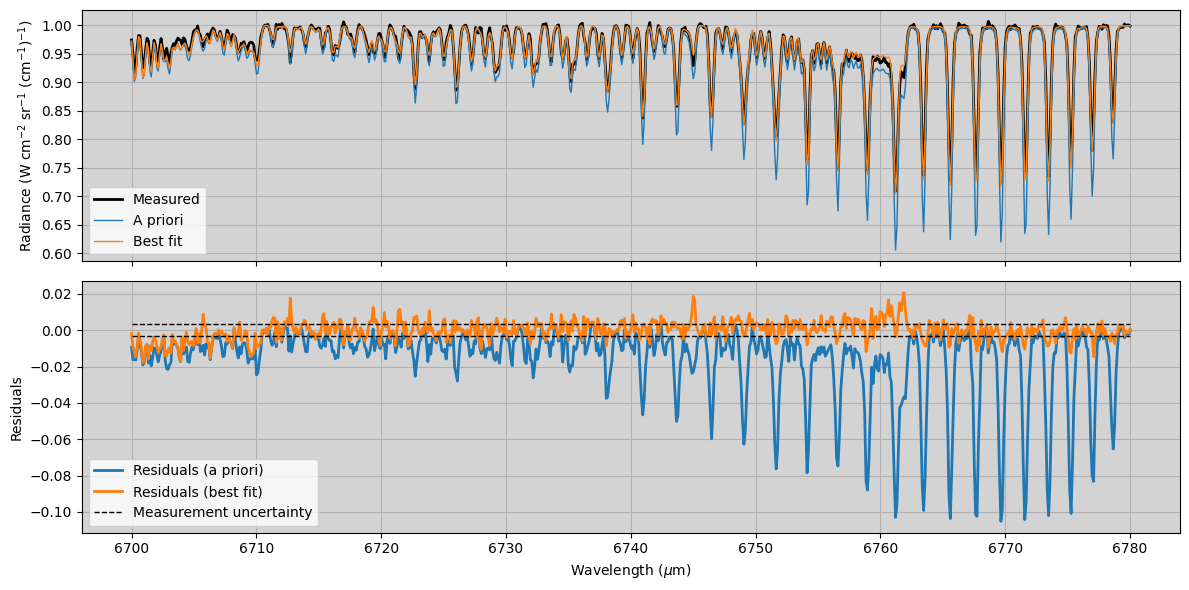

In [24]:
igeom = 0

#Making summary plot
fig,(ax1,ax2) = plt.subplots(2,1,figsize=(12,6),sharex=True)


ax1.plot(Measurement.VCONV[:,igeom],Measurement.MEAS[:,igeom],label='Measured',c='black',linewidth=2.)
ax1.plot(Measurement.VCONV[:,igeom],SPECONV_apr[:,igeom],label='A priori',linewidth=1.)
ax1.plot(Measurement.VCONV[:,igeom],Measurement.SPECMOD[:,igeom],label='Best fit',linewidth=1.)

ax2.plot(Measurement.VCONV[:,igeom],SPECONV_apr[:,igeom]-Measurement.MEAS[:,igeom],linewidth=2.,label='Residuals (a priori)')
ax2.plot(Measurement.VCONV[:,igeom],Measurement.SPECMOD[:,igeom]-Measurement.MEAS[:,igeom],linewidth=2.,label='Residuals (best fit)')
ax2.plot(Measurement.VCONV[:,igeom],Measurement.ERRMEAS[:,igeom],c='black',linewidth=1,label='Measurement uncertainty',linestyle='--')
ax2.plot(Measurement.VCONV[:,igeom],-Measurement.ERRMEAS[:,igeom],c='black',linewidth=1,linestyle='--')
ax2.legend()

ax1.grid()
ax2.grid()
ax1.legend()
ax1.set_facecolor('lightgray')
ax2.set_facecolor('lightgray')
ax2.set_xlabel('Wavelength ($\mu$m)')
ax1.set_ylabel('Radiance (W cm$^{-2}$ sr$^{-1}$ (cm$^{-1}$)$^{-1}$)')
ax2.set_ylabel('Residuals')
plt.tight_layout()

### 6.2. Reading the results for the fitted parameters

In [20]:
#Reading output parameters
nvar,nxvar,varident,varparam,aprparam,aprerrparam,retparam,reterrparam = ans.Files.read_retparam_hdf5(filename)

#Calculating the atmospheric number density (m-3)
numdens = Atmosphere.calc_numdens()

#Calculating the a priori number density of 13CO2 of our reference atmosphere
apr_density = numdens * aprparam[:,0]    

#Calculating the retrieved number density of 13CO2
ret_density = numdens * retparam[:,0]   
ret_density_err = numdens * reterrparam[:,0]   

In this case, since we are performing a synthetic retrieval, we can also see what was the "true" $^{13}$CO$_2$ density that was used to generate the synthetic spectrum. We just need to read the Atmosphere from the same file we read the Measurement from. 

In [21]:
Atmosphere_True = ans.Atmosphere_0()
Atmosphere_True.read_hdf5("synthetic_ini_file")

#Calculating the total atmospheric density (m-3)
numdens_true = Atmosphere_True.calc_numdens()

#Locating 13CO2 in the Atmosphere class
igas = Atmosphere_True.locate_gas(2,2)

#Calculating the partial density of 13CO2
true_density = numdens_true * Atmosphere_True.VMR[:,igas]

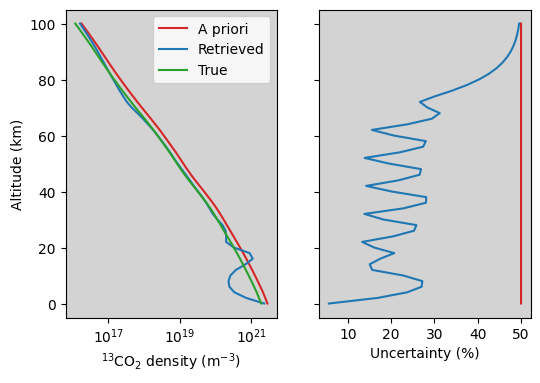

In [23]:
fig,(ax1,ax2) = plt.subplots(1,2,figsize=(6,4),sharey=True)

ivar = 0

capr = "tab:red"
cret = "tab:blue"
ctrue = "tab:green"

ax1.plot(apr_density,Atmosphere.H/1.0e3,label="A priori",c=capr)
ax1.plot(ret_density,Atmosphere.H/1.0e3,label="Retrieved",c=cret)
ax1.plot(true_density,Atmosphere_True.H/1.0e3,label="True",c=ctrue)
ax1.set_xscale("log")
ax1.set_facecolor("lightgray")
ax1.set_ylabel("Altitude (km)")
ax1.set_xlabel("$^{13}$CO$_2$ density (m$^{-3}$)")

ax2.plot(aprerrparam[:,ivar]/aprparam[:,ivar]*100.,Atmosphere.H/1.0e3,label="A priori",c=capr)
ax2.plot(reterrparam[:,ivar]/retparam[:,ivar]*100.,Atmosphere.H/1.0e3,label="Retrieved",c=cret)
ax2.set_facecolor("lightgray")
ax2.set_xlabel("Uncertainty (%)")

ax1.legend()